## Setting up environment for Colab

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import sys
from google.colab import userdata

config_path = userdata.get('CONFIG_PATH')

sys.path.append(config_path)

from config import BASE_PATH, DATA_PATH, SRC_PATH, SAVED_CHECKPOINTS_PATH

# Week 3 — Session 1 a: Advanced Models & Tree Ensembles

Last week, we explored **baseline models** like logistic regression, decision trees, and simple rule-based classifiers.  
Now it’s time to level up with **advanced supervised learning algorithms** that can capture **nonlinear patterns** and more complex feature interactions.

---

## What We’ll Do Today

**Demonstration:**  
- Start with a **Decision Tree** from week 2 session 2.  
- Scale up to a **Random Forest**, showing how ensembles improve performance and reduce overfitting.  
- Visualize how decision boundaries evolve as we combine more trees.
- Extend the tree-based models to try **XGBoost** — a popular gradient boosting method.  
- Train a **simple Neural Network** for comparison.  
- Compare these models using accuracy, precision, recall, F1-score, and visualization tools like ROC curves.  
- Analyze **computational cost** and trade-offs (training time, memory).

---

## Why This Matters

- Random forests are more robust than single decision trees because their ensemble averaging reduces the impact of noise and outliers on predictions.
- Comparing different algorithms on the same task helps you choose the best tool for your problem.
- Understanding training time and resource needs is critical for real-world deployment.

## Libraries We’ll Use

For this session we’ll need:

- **scikit-learn** — decision tree, random forest, metrics, train/test split  
- **xgboost** — gradient boosting trees  
- **torch** — simple neural network (PyTorch)  
- **matplotlib** & **seaborn** — to visualize decision boundaries and compare models  
- **time** — to measure training and inference time for computational cost analysis
- **transformers** - to create and train the transformer model

---

✅ Make sure `scikit-learn`, `xgboost`, `torch`, `seaborn`, and `matplotlib` are
installed.

In [ ]:
!pip install scikit-learn xgboost torch matplotlib seaborn transformers

In [ ]:
!pip install {SRC_PATH}

Processing ./drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/src
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.9 MB/s eta 0:00:00
  Created wheel for misinformation_detection: filename=misinformation_detection-1.0.0-py3-none-any.whl size=20155 sha256=29825e6af939809e3ed87106a155ad0c6393a9299a59bd364b5ffb62d1f7d081
  Stored in directory: /tmp/pip-ephem-wheel-cache-q5ot0vyj/wheels/46/67/19/6967c24d7ffe355b16d9bd45b2a6576a3fa548c7b58c981aee
Successfully built misinformation_detection


## Step 1 — Preparing the Data: Combining Structured & Text Features

In this session, we’re building **advanced models** that can learn from both:
- **Structured metadata & linguistic features** (like word count, readability, clickbait flag, source domain one-hots)
- **Unstructured text features** (using TF-IDF on our lemmatized article text)

---

### Why Combine Both?

- Metadata and linguistic cues often provide powerful signals that text alone might miss.
- TF-IDF captures word-level patterns, while numerical features add context about source, style, and structure.

---

### How We’ll Do It

If you recall, we already created the function that allows us to combine TFIDF features with the other structured features we created earlier. The steps followed were:

1. **Split the data** into train and test sets first (to avoid data leakage).  
2. **Fit the TF-IDF vectorizer only on the training text** and transform the test text with the same vocabulary.  
3. **Combine** the sparse TF-IDF matrix with the numerical features to create a single feature matrix for each split.

---

**By merging these together**, we give our decision tree and random forest models a **richer, more diverse set of signals** — boosting their ability to detect subtle patterns in misinformation.

In [ ]:
from misinformation_detection.data import prepare_text_structured_features_full
from pathlib import Path

X_train_combined, X_test_combined, X_structured_train_full, X_structured_test_full, y_train, y_test, vectorizer = prepare_text_structured_features_full(
    DATA_PATH / Path("processed/fnn_lemmatized.csv")
)

## Decision Tree Classifier

Now that our combined dataset is ready, let’s use the same code we set up for our **Decision Tree** from week 2 session 2, but now using the mix of structured and TFIDF features

This gives us an interpretable baseline and demonstrates how a single tree works before moving to **Random Forests** or **boosting ensembles**.

Decision Tree Training Time: 1.2437 seconds
Decision Tree Inference Time: 0.000002 seconds/sample
TF-IDF Decision Tree Metrics
Accuracy: 0.8057
Precision: 0.7012
Recall: 0.2746
F1-Score: 0.3946
TF-IDF Decision Tree Expected Cost
  False Positive Rate : 0.0351
  False Negative Rate : 0.7254
  Expected Cost       : 3.6973
----------------------------------------
TF-IDF Decision Tree Operational Efficiency
  Auto-approved (%): 89.60%
----------------------------------------


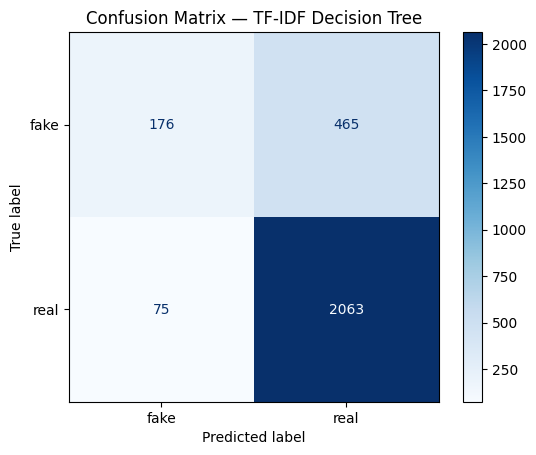

<Figure size 600x500 with 0 Axes>

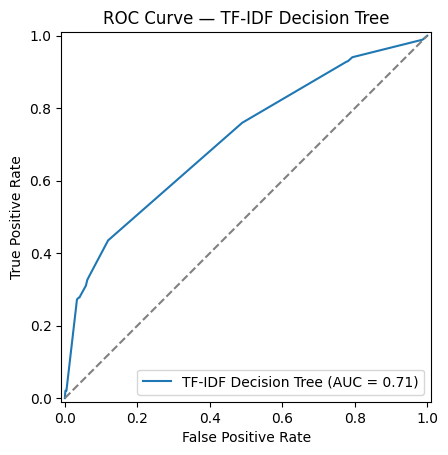

ROC AUC: 0.7136


<Figure size 600x500 with 0 Axes>

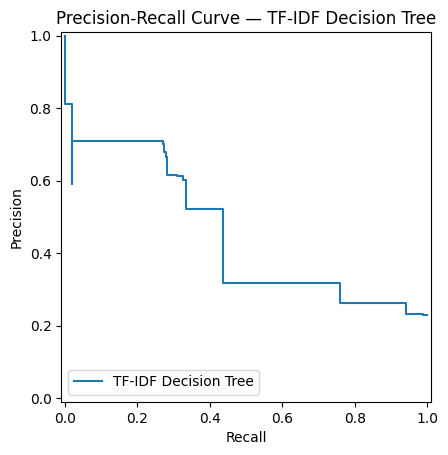

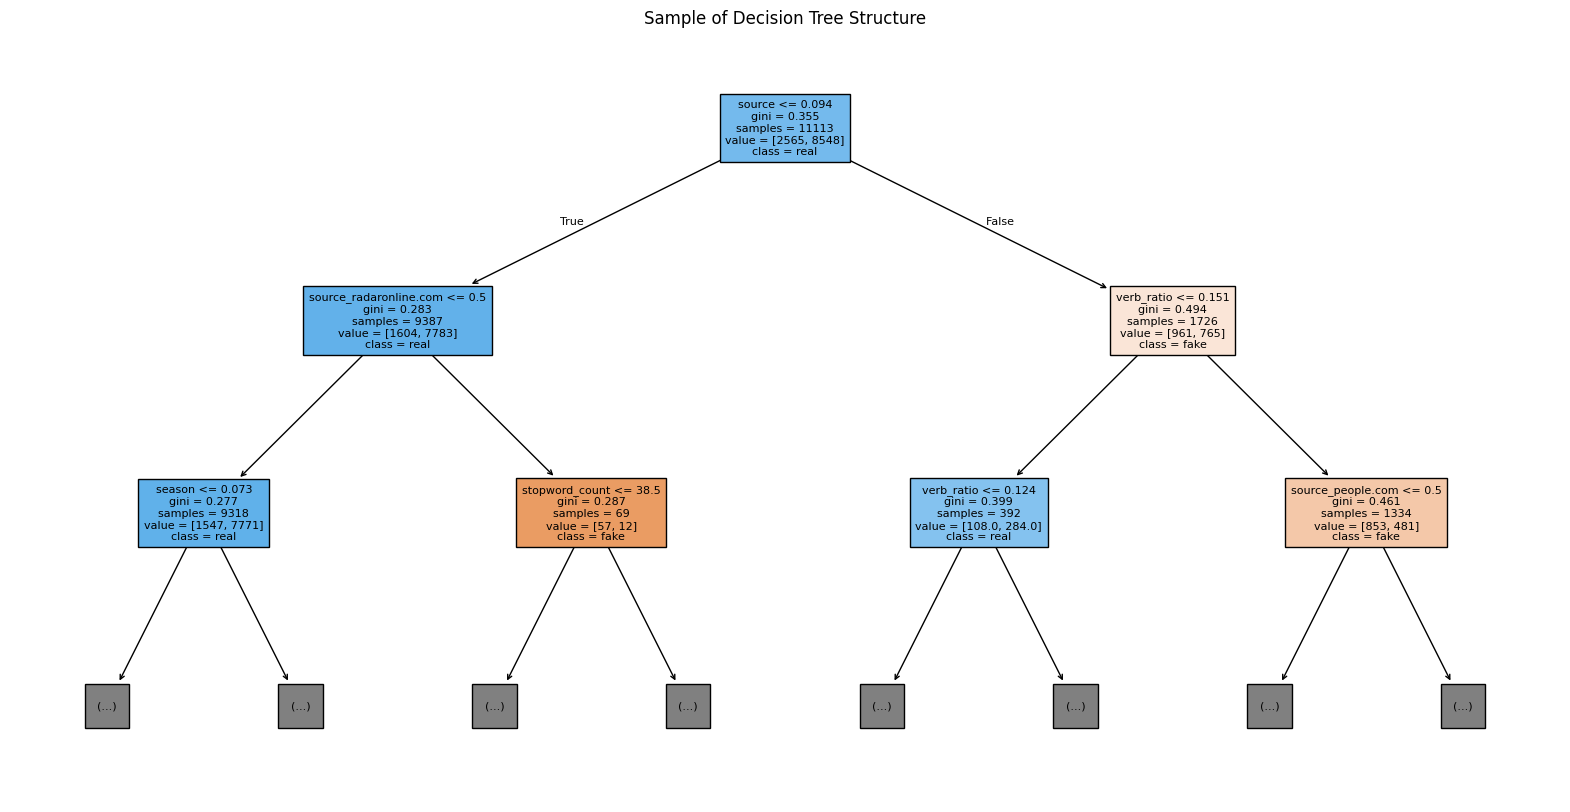

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from misinformation_detection.models import DecisionTreeBaseline
import time

# 1. Load the trained tree
tree_clf = DecisionTreeBaseline()

# --- Training Time ---
start_time = time.time()
tree_clf.fit(X_train_combined, y_train)
dt_train_time = time.time() - start_time
print(f"Decision Tree Training Time: {dt_train_time:.4f} seconds")

# --- Inference Time ---
start_time = time.time()
tree_clf.predict(X_test_combined)
end_time = time.time()
# Calculate time per sample
dt_inference_time = (end_time - start_time) / len(X_test_combined)
print(f"Decision Tree Inference Time: {dt_inference_time:.6f} seconds/sample")

tree_clf.eval(X_test_combined, y_test)

# 5. Optional: Plot the tree structure (for small trees)
plt.figure(figsize=(20, 10))
plot_tree(tree_clf.model,
          feature_names=X_train_combined.columns,
          class_names=tree_clf.model.classes_,
          filled=True, max_depth=2, fontsize=8)
plt.title("Sample of Decision Tree Structure")
plt.show()


## Decision Tree Classifier — Results & Insights

The simple **Decision Tree** has been trained with both TF-IDF and structured features.  
Here’s what we can see from the results:

---

### **Performance Metrics**

The tree achieves reasonable accuracy but struggles with recall for fake news — showing that deeper splits or more advanced ensembles may help.

---

### **Confusion Matrix**
The confusion matrix shows:
- Many real news items correctly identified.
- Some fake news articles still being predicted as real.

---

### **Sample Tree Visualization**
The small tree plot illustrates:
- How the model uses features like `season`, `source` domains, `verb_ratio` to split.
- Early splits show what the model thinks are strong signals for real vs. fake.
- Useful to interpret how decision paths are formed.

---

### **Key Takeaway**
Decision Trees are:
- Easy to interpret and visualize.
- Serve as a baseline for comparing more robust ensembles like Random Forests or XGBoost.


## Random Forest Classifier — Why Go Beyond a Single Tree?

Now that we've trained a single Decision Tree, it’s time to see how **tree ensembles** can help.

---

### **Why Random Forests?**

A **Random Forest**:
- Combines **many shallow trees** trained on different random samples of the data.
- Uses **feature bagging** (random subsets of features) for each split.
- Aggregates predictions by **majority vote** (for classification).

This reduces:
- **Overfitting**, which is common with a single deep tree.
- Sensitivity to noise in the training data.

---

### **Benefits**
- Usually achieves **higher accuracy** and better generalization.
- More robust than a single tree.
- Still interpretable: you can inspect feature importances instead of one huge tree.

---

### **What We'll Do**
- Fit a Random Forest on the combined TF-IDF + structured features.
- Compare its metrics to the single tree.
- Visualize **feature importances** to see which signals are most valuable.
- Discuss trade-offs: more trees = better results but higher computational cost.


Random Forest Training Time: 6.6199 seconds
Random Forest Inference Time: 0.000022 seconds/sample
Random Forest Accuracy:  0.8168
Precision:               0.8882
Recall:                  0.2356
F1-Score:                0.3724


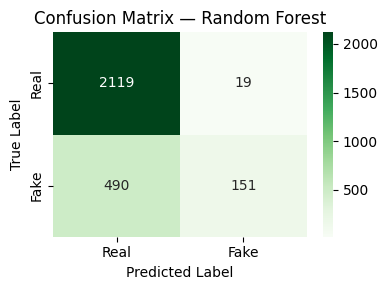

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and train
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1  # use all cores
)

# --- Training Time ---
start_time = time.time()
rf_clf.fit(X_train_combined, y_train)
rf_train_time = time.time() - start_time
print(f"Random Forest Training Time: {rf_train_time:.4f} seconds")

# --- Inference Time ---
start_time = time.time()
# 2. Predict
rf_preds = rf_clf.predict(X_test_combined)
end_time = time.time()
rf_inference_time = (end_time - start_time) / len(X_test_combined)
print(f"Random Forest Inference Time: {rf_inference_time:.6f} seconds/sample")

# 3. Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, pos_label="fake")
rf_recall = recall_score(y_test, rf_preds, pos_label="fake")
rf_f1 = f1_score(y_test, rf_preds, pos_label="fake")

print(f"Random Forest Accuracy:  {rf_acc:.4f}")
print(f"Precision:               {rf_precision:.4f}")
print(f"Recall:                  {rf_recall:.4f}")
print(f"F1-Score:                {rf_f1:.4f}")

# 4. Confusion Matrix
cm = confusion_matrix(y_test, rf_preds, labels=["real", "fake"])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


In [ ]:
# Save model

filepath = SAVED_CHECKPOINTS_PATH/ Path("random_forest_model.joblib")
joblib.dump(rf_clf, filepath)

['/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/random_forest_model.joblib']

## Random Forest Results & Interpretation

- **Confusion Matrix:**  
  The Random Forest achieved an overall **accuracy of ~81.5%**, with very **high precision (90%)** for predicting *fake news*.  
  However, the **recall is lower (~30%)**, meaning it misses a significant portion of fake news articles.  
  This shows the model is conservative in flagging fake news but very confident when it does.

- **Feature Importances:**  
  The top features show that the model relies heavily on:
  - The **`source`** feature, which dominates split decisions.
  - Other strong signals like **`source_hollywoodlife.com`**, **`verb_ratio`**, and some word-level TF-IDF features.
  - This demonstrates how an ensemble can combine multiple weak signals to create stronger predictions.

**Key Insight:**  
Random Forests improve over single decision trees by combining multiple trees to reduce overfitting and variance.  
The drop in recall suggests that class imbalance or threshold tuning could help catch more fake news cases.  
In the next step, we’ll try other ensemble methods like **XGBoost** to see if boosting helps balance precision and recall better.

## XGBoost Classifier

Now let’s add another powerful tree-based ensemble: **XGBoost** (Extreme Gradient Boosting).

---

### Why Use XGBoost?

- Uses **gradient boosting**, which builds trees sequentially to correct previous errors.
- Known for **high accuracy**, especially on tabular data.
- Provides **feature importance scores** for interpretation.

---

### What We’ll Do:

1. **Train** an `XGBClassifier` on the combined TF-IDF + structured features.
2. **Predict** on the test set.
3. **Evaluate** using accuracy, precision, recall, and F1-score.
4. **Visualize** the confusion matrix to inspect predictions.

---

> **Pro Tip:**  While XGBoost is more powerful than a single decision tree, it may need tuning for best results.  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:45:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Time: 10.0593 seconds
XGBoost Inference Time: 0.000015 seconds/sample
XGBoost Accuracy:  0.8233
Precision:         0.7641
Recall:            0.3385
F1-Score:          0.4692


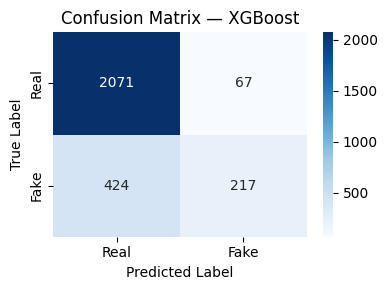

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert labels to numeric: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# 1. Initialize and train
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

# --- Training Time ---
start_time = time.time()
xgb_clf.fit(X_train_combined, y_train_encoded)
xgb_train_time = time.time() - start_time
print(f"XGBoost Training Time: {xgb_train_time:.4f} seconds")

# 2. Predict

# --- Inference Time ---
start_time = time.time()
xgb_preds = xgb_clf.predict(X_test_combined)
end_time = time.time()
xgb_inference_time = (end_time - start_time) / len(X_test_combined)
print(f"XGBoost Inference Time: {xgb_inference_time:.6f} seconds/sample")

# 3. Evaluate
xgb_acc = accuracy_score(y_test_encoded, xgb_preds)
xgb_precision = precision_score(y_test_encoded, xgb_preds)
xgb_recall = recall_score(y_test_encoded, xgb_preds)
xgb_f1 = f1_score(y_test_encoded, xgb_preds)

print(f"XGBoost Accuracy:  {xgb_acc:.4f}")
print(f"Precision:         {xgb_precision:.4f}")
print(f"Recall:            {xgb_recall:.4f}")
print(f"F1-Score:          {xgb_f1:.4f}")

# 4. Confusion Matrix
cm = confusion_matrix(y_test_encoded, xgb_preds, labels=[0, 1])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
# Save model

filepath = SAVED_CHECKPOINTS_PATH / Path("xgboost_model.joblib")
joblib.dump(xgb_clf, filepath)

['/content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/xgboost_model.joblib']

## Simple Neural Network for Misinformation Detection

Now that we’ve tried tree-based models and boosting, let’s experiment with a **basic neural network** using **PyTorch**.  
A simple feedforward network can learn non-linear interactions in the combined TF-IDF + structured feature set.

---

### How This Works

1. ** What’s a Neural Network?**  
A neural network is a series of connected layers where each layer transforms the input using learned weights and activation functions.  
It can learn complex patterns that linear models (like logistic regression) might miss.

---

2. **Defining the Model in PyTorch**  
We’ll use `torch.nn.Module` to define:
- An **input layer** matching your feature count.
- One or more **hidden layers** with non-linear activations like ReLU.
- An **output layer** with a single neuron for binary classification.

---

3. **The Training Loop**  
A typical PyTorch training loop involves:
- Forward pass: compute predictions.
- Calculate **loss** (e.g., Binary Cross-Entropy Loss).
- Backward pass: compute gradients.
- Update weights with an optimizer like Adam.

We’ll also track the **validation loss** on the test set after each epoch to monitor overfitting.

---

4. **Visualizing Training Progress**  
After training, plot:
- **Training loss** and **validation loss** over epochs.
- Look for signs of **overfitting**: training loss keeps decreasing but validation loss increases.
- If the losses don’t decrease or diverge wildly, we might need to adjust learning rate, batch size, or model architecture.

---

**Key Points to Watch**
- Always shuffle and batch your data.
- Use early stopping if validation loss worsens.
- Start simple: just 1–2 hidden layers often work well for tabular/text features.

This gives us a flexible, non-linear baseline to compare with our decision trees, random forest, and XGBoost!

## Define The Simple Neural Network (PyTorch)

Let’s define a **basic feedforward neural network** using PyTorch.

---

### **Key points:**

- **Input dimension:**  
  Matches the number of features we prepared.

- **Architecture:**  
  - One hidden layer with 64 units (ReLU)
  - Another hidden layer with 32 units (ReLU)
  - Output layer with 1 unit and a sigmoid activation for **binary classification** (`real` vs. `fake`).

- **Why ReLU + Sigmoid?**  
  - ReLU helps the model learn non-linear patterns efficiently.
  - Sigmoid squashes the output to [0, 1], making it interpretable as a probability.

---

### **Inspect the model:**  
Always print your model structure to verify input/output shapes.

Use this block to define and check your simple network!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Number of input features — get from your combined training set
input_dim = X_train_combined.shape[1]

# Define a simple feedforward network
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)  # Binary output

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.output(x))  # Sigmoid for binary
        return x

# Instantiate model
model = SimpleNN(input_dim)
print(model)

SimpleNN(
  (fc1): Linear(in_features=131, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


## Split Final Test Set into Validation & Test

To properly monitor the model’s generalization, it’s good practice to split the original test set one more time:

- **Why?**  
  - We need a **validation set** for tuning hyperparameters and monitoring training progress.
  - We need a **final hold-out test set** for unbiased final evaluation.

---

### What this does:
- Uses `train_test_split` to divide the test data:  
  - 50% goes to validation  
  - 50% remains for final testing
- Keeps the class distribution balanced with `stratify`.

---

Check your splits to confirm the shapes look reasonable!

In [ ]:
from sklearn.model_selection import train_test_split

# Split test set: 50% validation, 50% final test
X_val, X_final_test, y_val, y_final_test = train_test_split(
    X_test_combined,
    y_test,
    test_size=0.5,
    random_state=42,
    stratify=y_test
)

print(f"Validation set: {X_val.shape}, Final test set: {X_final_test.shape}")

Validation set: (1389, 131), Final test set: (1390, 131)


## Create PyTorch Datasets & DataLoaders

With the final training and validation sets ready, this step prepares our data for efficient neural network training.

---

### What this block does:

1. **Convert bools to int:**  
   Neural networks expect numeric inputs — so convert any `bool` columns to `int` (0 or 1).

2. **Align indexes:**  
   Reset the DataFrame and label indexes to ensure the features and labels align row by row.

3. **Convert to tensors:**  
   Use `torch.tensor()` to convert our NumPy arrays into PyTorch tensors, which can be fed into our model.

4. **Wrap in `TensorDataset` & `DataLoader`:**  
   - `TensorDataset` pairs each feature vector with its label.
   - `DataLoader` handles batching and shuffling for us.

5. **Check sizes:**  
   Print the number of batches for training and validation to make sure everything looks correct.

---

This ensures the neural network will see data in mini-batches and that our labels are in the correct format.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Make sure bools are converted to int
bool_cols_train = X_train_combined.select_dtypes(include="bool").columns
bool_cols_val = X_val.select_dtypes(include="bool").columns
bool_cols_test = X_final_test.select_dtypes(include="bool").columns

X_train_combined[bool_cols_train] = X_train_combined[bool_cols_train].astype(int)
X_val[bool_cols_val] = X_val[bool_cols_val].astype(int)
X_final_test[bool_cols_test] = X_final_test[bool_cols_test].astype(int)

# 2. Reset index to align with labels
X_train_combined = X_train_combined.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

# 3. Convert to tensors
X_train_tensor = torch.tensor(X_train_combined.values, dtype=torch.float32)
y_train_tensor = torch.tensor((y_train == "fake").astype(int).values, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor((y_val == "fake").astype(int).values, dtype=torch.float32).unsqueeze(1)

# 4. Wrap in TensorDataset and DataLoader
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

# 5. Confirm sizes
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 174
Validation batches: 22


## Neural Network Training Loop with Checkpointing

Below is the PyTorch training loop for the simple neural network, now with a **device check** and **checkpoint saving**.

---

### **Key parts:**

1. **Device Selection:**
   - Checks for CUDA first, then Apple MPS, then CPU fallback.
   - Moves the model and each batch to the selected device.

2. **Model, Loss, Optimizer:**
   - `SimpleNN` is our model.
   - `BCELoss` for binary classification with a sigmoid output.
   - `Adam` optimizer for smooth weight updates.

3. **Training Phase:**
   - `model.train()` enables gradient updates.
   - For each batch:
     - Zero gradients.
     - Forward pass → compute loss → backward pass → update weights.

4. **Validation Phase:**
   - `model.eval()` disables gradient tracking.
   - `torch.no_grad()` saves memory during validation.
   - Computes and tracks validation loss.

5. **Checkpointing:**
   - If the current validation loss is the lowest seen, save model weights as the **best checkpoint**.
   - At the end, save both:
     - The **final model** after all epochs.
     - The **best model** based on validation loss.

6. **Progress Tracking:**
   - Stores training and validation losses for plotting.
   - Prints losses each epoch so you can monitor for overfitting.

---

This ensures we keep our best model version even if our final training overshoots.

In [ ]:
import torch
import torch.optim as optim

# Device check
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Model, loss, optimizer
model = SimpleNN(X_train_combined.shape[1]).to(device)
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 150
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

# Start timer before the loop
start_train = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Save best model so far
    if val_loss < best_val_loss:
        # Update best validation loss and model state
        print(f"New best validation loss: {val_loss:.4f} (previous: {best_val_loss:.4f})")
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")


# Stop timer after the loop finishes
nn_train_time = time.time() - start_train
print(f"Neural Network Training Time: {nn_train_time:.4f} seconds")

# Save final model
torch.save(model.state_dict(), SAVED_CHECKPOINTS_PATH / Path("model_final.pt"))

# Save best model by val loss
torch.save(best_model_state, SAVED_CHECKPOINTS_PATH / Path("model_best_val_loss.pt"))

print(f"Training complete. Final model and best validation-loss model saved.")

Using device: cpu
New best validation loss: 0.5534 (previous: inf)
Epoch [1/150] - Train Loss: 0.7543, Val Loss: 0.5534
New best validation loss: 0.5357 (previous: 0.5534)
Epoch [2/150] - Train Loss: 0.5685, Val Loss: 0.5357
Epoch [3/150] - Train Loss: 0.5366, Val Loss: 0.5690
New best validation loss: 0.5152 (previous: 0.5357)
Epoch [4/150] - Train Loss: 0.5286, Val Loss: 0.5152
New best validation loss: 0.5092 (previous: 0.5152)
Epoch [5/150] - Train Loss: 0.5210, Val Loss: 0.5092
New best validation loss: 0.5005 (previous: 0.5092)
Epoch [6/150] - Train Loss: 0.5179, Val Loss: 0.5005
New best validation loss: 0.4660 (previous: 0.5005)
Epoch [7/150] - Train Loss: 0.4979, Val Loss: 0.4660
Epoch [8/150] - Train Loss: 0.4918, Val Loss: 0.4983
New best validation loss: 0.4543 (previous: 0.4660)
Epoch [9/150] - Train Loss: 0.4747, Val Loss: 0.4543
Epoch [10/150] - Train Loss: 0.4685, Val Loss: 0.4602
Epoch [11/150] - Train Loss: 0.4703, Val Loss: 0.4609
Epoch [12/150] - Train Loss: 0.4546,

## Visualize Training and Validation Loss

Use this simple plot to track how your neural network is learning:

- **Blue line**: Training loss  
- **Orange line**: Validation loss  

If the gap between training and validation loss widens too much, your model might be overfitting.  
Ideally, both should decrease smoothly and stay close together.

This helps you decide when to stop training, tune hyperparameters, or adjust your model complexity.

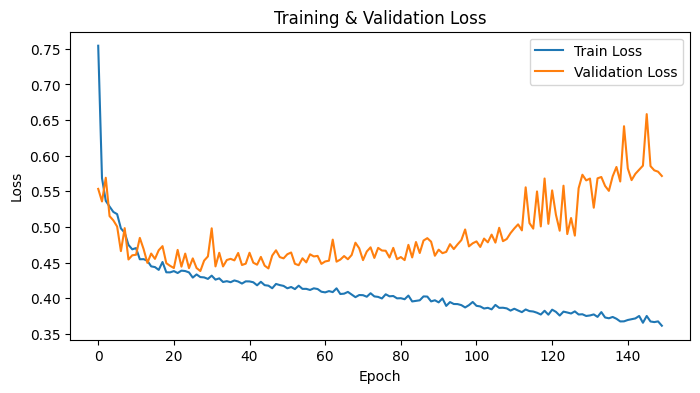

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

## Training & Validation Loss — What It Shows

- **Blue line (Train Loss)**: Decreases steadily, showing the model is learning patterns in the training data.
- **Orange line (Validation Loss)**: Fluctuates and stays higher than the training loss.

### What to Notice:
It’s good that the training loss is decreasing smoothly.  
The validation loss is noisy and doesn’t consistently trend downward — this could be due to:
- Small batch size or learning rate instability.
- Overfitting: the model learns training data well but struggles to generalize.
- Insufficient regularization.

### Next Steps:
- Try adding dropout, weight decay, or early stopping.
- Consider tuning learning rates or using a scheduler.
- Monitor whether validation loss smooths out with more epochs or different hyperparameters.

Good practice: Always plot this to spot overfitting early!

In [ ]:
import torch

# Make sure your test DataLoader exists
from torch.utils.data import TensorDataset, DataLoader

# Convert final test set to tensor
X_test_tensor = torch.tensor(X_final_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(
    (y_final_test == "fake").astype(int).to_numpy(),
    dtype=torch.float32
).unsqueeze(1)

test_ds = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_ds, batch_size=64)

# Load final model
final_model = SimpleNN(X_train_combined.shape[1])
final_model.load_state_dict(torch.load(SAVED_CHECKPOINTS_PATH / Path("model_final.pt")))
final_model = final_model.to(device)
final_model.eval()

# Load best val loss model
best_model = SimpleNN(X_train_combined.shape[1])
best_model.load_state_dict(torch.load(SAVED_CHECKPOINTS_PATH / Path("model_best_val_loss.pt")))
best_model = best_model.to(device)
best_model.eval()

# Function to evaluate
def evaluate_model(model, loader):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            outputs = model(xb)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    acc = (preds == labels).float().mean().item()
    return acc

# --- Inference Time ---
start_time = time.time()
# Run evaluation on the test set
evaluate_model(final_model, test_loader)
end_time = time.time()

# Calculate time per sample (using the size of the final test set)
nn_inference_time = (end_time - start_time) / len(X_final_test)
print(f"Neural Network Inference Time: {nn_inference_time:.6f} seconds/sample")

final_acc = evaluate_model(final_model, test_loader)
best_acc = evaluate_model(best_model, test_loader)

print(f"Final Model Test Accuracy: {final_acc:.4f}")
print(f"Best Val Loss Model Test Accuracy: {best_acc:.4f}")

Neural Network Inference Time: 0.000024 seconds/sample
Final Model Test Accuracy: 0.8122
Best Val Loss Model Test Accuracy: 0.8122


## Computational Cost Comparison

To evaluate the computational efficiency of different models, we compare their training and inference times as well as resource usage. The table below summarizes these metrics for all models tested.

| Model                  | Training Time (s) | Inference Time (s/sample) | Hardware Used       |
|------------------------|------------------|---------------------------|---------------------|
| Decision Tree          | 1.2437           |  0.000002                 | CPU                 |
| Random Forest          | 6.6199           | 0.000022                  | CPU                 |
| XGBoost                | 10.0593          | 0.000015                  | CPU                 |
| Simple Neural Network  | 102.4838         | 0.000024                  | CPU             |

This comparison provides insight into the trade-offs between model complexity, training duration, and real-time usability for misinformation detection tasks.


## Let's pack everything up!

Same as we've been doing in each session, it's time we neatly package these models into classes and save them in our src folder!

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For saving and loading models

class RandomForestModel:
    def __init__(self, n_estimators=100, max_depth=10, random_state=42, n_jobs=-1):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=n_jobs
        )
        self.is_trained = False

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        self.is_trained = True

    def predict(self, X):
        if not self.is_trained:
            raise RuntimeError("Model must be trained before prediction.")
        return self.model.predict(X)

    def evaluate(self, X_test, y_test, pos_label=1):
        preds = self.predict(X_test)
        acc = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds, pos_label=pos_label)
        recall = recall_score(y_test, preds, pos_label=pos_label)
        f1 = f1_score(y_test, preds, pos_label=pos_label)
        cm = confusion_matrix(y_test, preds)
        print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
        self.plot_confusion_matrix(cm)
        return acc, precision, recall, f1

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix - Random Forest')
        plt.tight_layout()
        plt.show()

    def save_model(self, filepath):
        """Save the trained model to a file."""
        if not self.is_trained:
            raise RuntimeError("Cannot save an untrained model.")
        joblib.dump(self.model, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath):
        """Load a trained model from a file."""
        self.model = joblib.load(filepath)
        self.is_trained = True
        print(f"Model loaded from {filepath}")


In [ ]:
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class XGBoostModel:
    def __init__(self, **params):
        self.model = XGBClassifier(
            **params
        )
        self.is_trained = False

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        self.is_trained = True

    def predict(self, X):
        if not self.is_trained:
            raise RuntimeError("Model must be trained before prediction.")
        return self.model.predict(X)

    def evaluate(self, X_test, y_test, pos_label=1, verbose=True):
        preds = self.predict(X_test)
        acc = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds, pos_label=pos_label)
        recall = recall_score(y_test, preds, pos_label=pos_label)
        f1 = f1_score(y_test, preds, pos_label=pos_label)
        cm = confusion_matrix(y_test, preds)
        if verbose:
            print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
            self.plot_confusion_matrix(cm)
        return acc, precision, recall, f1

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix - XGBoost')
        plt.tight_layout()
        plt.show()

    def save_model(self, filepath):
        if not self.is_trained:
            raise RuntimeError("Cannot save an untrained model.")
        joblib.dump(self.model, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath):
        self.model = joblib.load(filepath)
        self.is_trained = True
        print(f"Model loaded from {filepath}")
